In [ ]:
!pip install torch lightning torchvision torchmetrics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 30.2 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import BinaryAccuracy
from torch.utils.data import Dataset, DataLoader
import lightning as pl
from dataclasses import dataclass
from typing import Literal
import matplotlib.pyplot as plt

In [ ]:
@dataclass
class DatasetConfig:
  IMG_SIZE: int  = 64
  DOT_RADIUS: int = 2           # radius of the dot correlated with the label
  DOT_MARGIN:int  = 6           # distance to the border of the image
  SHAPE_SCALE: tuple[float, float] = (0.25, 0.45)  # shape size as a fraction of IMG_SIZE


class RenderingFunctions:

  @staticmethod
  def draw_circle(
        img: np.ndarray,
        cx: int,
        cy: int,
        r: int,
        value: float = 1.0
      )->None:
      # Draws a circle inplace
      H, W = img.shape
      for y in range(max(0, cy - r - 1), min(H, cy + r + 2)):
          for x in range(max(0, cx - r - 1), min(W, cx + r + 2)):
              if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
                  img[y, x] = value

  @staticmethod
  def draw_rect(
      img: np.ndarray,
      x0: int,
      y0: int,
      x1: int,
      y1: int,
      value: float = 1.0
    )->None:
    # Crete rectangle inplace
    img[y0:y1, x0:x1] = value

  @staticmethod
  def make_image(
        label: int,
        split: str,
        rng: random.Random,
        corr_prob:float,
        cfg:DatasetConfig
      ) -> np.ndarray:
      assert 0<=corr_prob<=1, 'Correlation proba has to be between 0 and 1'
      # Creates an image with the selected label (0 for circle and 1 for rectangle)
      # A dot is correlated with the label with a probability of 'corr_prob'

      img = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE), dtype=np.float32)

      # Select a size for the figure in the interval 'shape_scale'
      size_frac = rng.uniform(*cfg.SHAPE_SCALE)
      half = int(size_frac * cfg.IMG_SIZE / 2)

      # Random center position and keep shape fully inside
      margin = half + 2
      cx = rng.randint(margin, cfg.IMG_SIZE - margin - 1)
      cy = rng.randint(margin, cfg.IMG_SIZE - margin - 1)

      if label == 0:
          RenderingFunctions.draw_circle(img, cx, cy, half)
      else:
          RenderingFunctions.draw_rect(
              img,
              cx - half,
              cy - half,
              cx + half,
              cy + half
            )

      if split!='train_val':
        # At test time there's no correlation between
        # the position of the dot and the label
        # so place the dot randomly on the bottom left
        # or the bottom right
        dot_top_right = (rng.random()<=1/2)
      else:
        # At train/val correlate the label with the position of the dot
        # with a probability of 'corr_prob'

        # If it's a circle place a dot on bottom left with a proba of 'corr_prob'
        if label == 0:
          dot_top_right = (rng.random()<=corr_prob)
        # If it's a rect place a dot on bottom left with a proba of 'corr_prob'
        else:
          dot_top_right = (rng.random()>corr_prob)

      # Draw the dot
      if dot_top_right:
          dot_x, dot_y = cfg.IMG_SIZE - cfg.DOT_MARGIN, cfg.DOT_MARGIN
      else:
          dot_x, dot_y = cfg.DOT_MARGIN, cfg.IMG_SIZE - cfg.DOT_MARGIN

      RenderingFunctions.draw_circle(img, dot_x, dot_y, cfg.DOT_RADIUS, value=1.0)

      return img[np.newaxis]   # (1, H, W)


class ShapeDataset(Dataset):
    def __init__(
          self,
          n_samples: int,
          split: Literal['train_val', 'test'],
          corr_prob: float,
          cfg:DatasetConfig = DatasetConfig(),
          seed: int = 0
        ):
        rng = random.Random(seed)
        self.images = []
        self.labels = []
        for i in range(n_samples):
            label = rng.randint(0, 1)
            img   = RenderingFunctions.make_image(
                label,
                split,
                rng,
                corr_prob,
                cfg
              )
            self.images.append(torch.tensor(img))
            self.labels.append(label)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

class ShapeDataModule(pl.LightningDataModule):
    def __init__(
        self,
        corr_prob: float,
        cfg:DatasetConfig = DatasetConfig(),
        n_train:    int = 4000,
        n_val:      int = 1000,
        n_test:     int = 1000,
        batch_size: int = 256,
    ):
        super().__init__()
        self.n_train    = n_train
        self.n_val      = n_val
        self.n_test     = n_test
        self.batch_size = batch_size
        self.corr_prob = corr_prob
        self.cfg = cfg

    def setup(self, stage=None):
        self.train_ds = ShapeDataset(self.n_train, split='train_val', corr_prob=self.corr_prob, cfg=self.cfg,seed=1)
        self.val_ds   = ShapeDataset(self.n_val,   split='train_val', corr_prob=self.corr_prob, cfg=self.cfg, seed=2)
        self.test_ds  = ShapeDataset(self.n_test,  split='test',      corr_prob=self.corr_prob, cfg=self.cfg, seed=3)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True,  num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_ds,   batch_size=self.batch_size, shuffle=False, num_workers=2)

    def test_dataloader(self):
        return DataLoader(self.test_ds,  batch_size=self.batch_size, shuffle=False, num_workers=2)

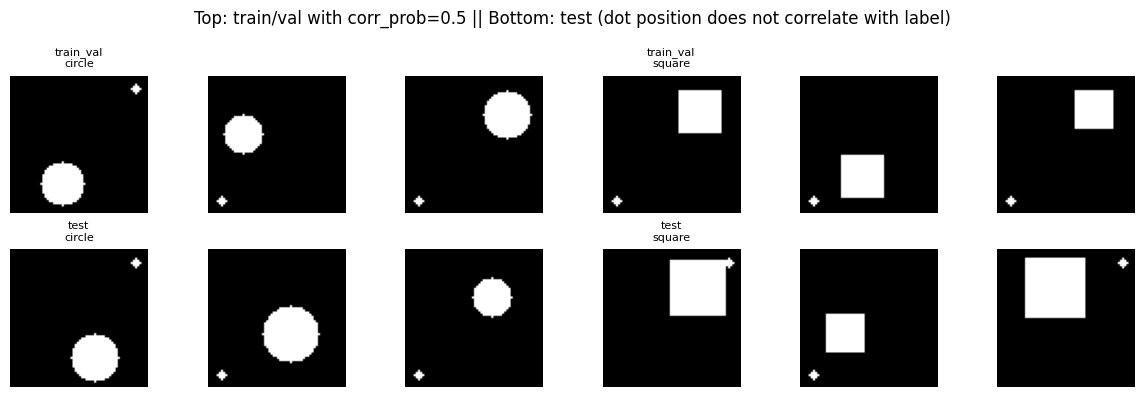

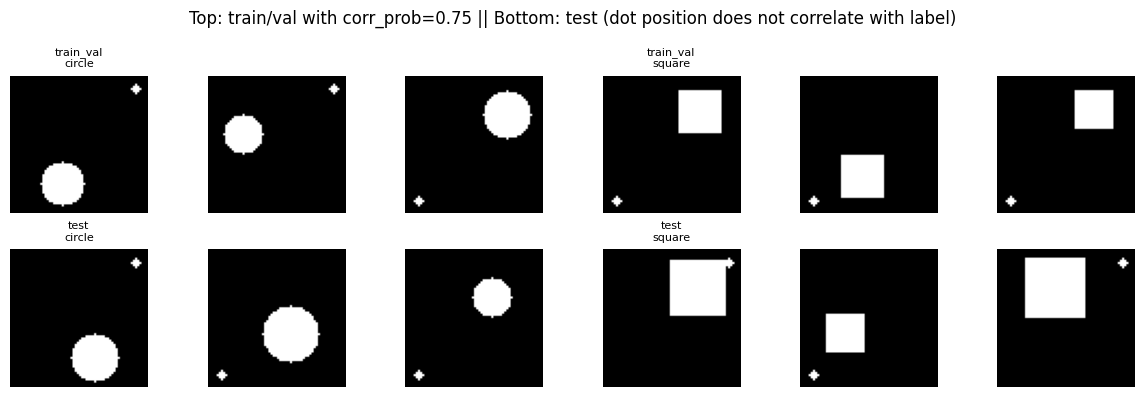

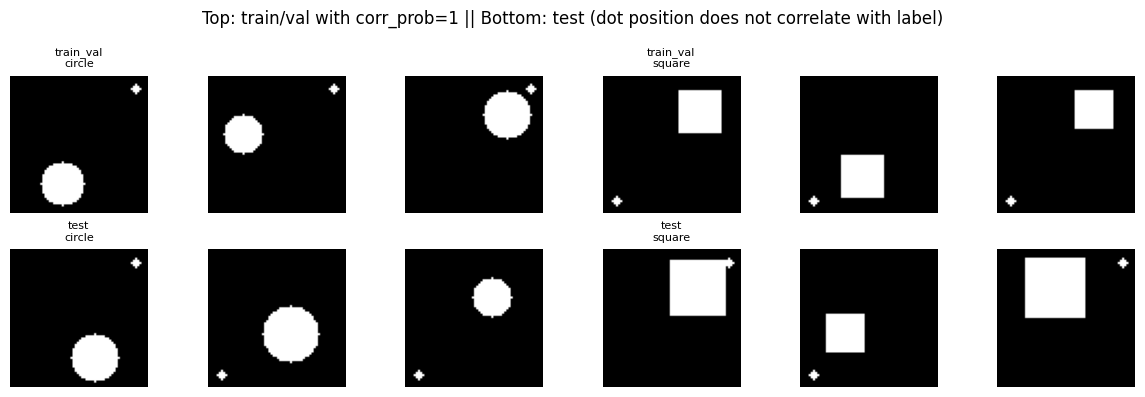

In [ ]:
def visualise_samples(corr_prob:float, n: int = 3):

    rng = random.Random(99)
    fig, axes = plt.subplots(2, n * 2, figsize=(n * 4, 4))

    for col, label in enumerate([0, 1]):
        lname = 'circle' if label == 0 else 'square'
        for row, split in enumerate(['train_val', 'test']):
            for i in range(n):
                ax = axes[row][col * n + i]
                img = RenderingFunctions.make_image(label, split, rng, corr_prob, DatasetConfig())[0]
                ax.imshow(img, cmap='gray', vmin=0, vmax=1)
                ax.axis('off')
                if i == 0:
                    ax.set_title(f"{split}\n{lname}", fontsize=8)

    plt.suptitle(f"Top: train/val with corr_prob={corr_prob} || Bottom: test (dot position does not correlate with label)")
    plt.tight_layout()

for c_prob in [0.5, 0.75, 1]:
  visualise_samples(corr_prob=c_prob)

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(
          self,
          H: int,
          W: int,
          in_channels: int = 1,
          num_classes: int = 2
          ):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, in_channels*5, 8),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels * 5, (in_channels * 5) * 2, 5),
            nn.MaxPool2d(2),
            nn.Flatten()
        )

        with torch.no_grad():
          dummy = torch.zeros((1, in_channels, H, W))
          feature_shape = self.features(dummy).shape
          n_features = feature_shape[1]

        self.classifier = nn.Linear(n_features, num_classes)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class ViT(nn.Module):

    def __init__(
        self,
        H : int,
        W: int,
        patch_size:  int = 8,
        in_chans:    int = 1,
        embed_dim:   int = 64,
        depth:       int = 2,
        n_heads:     int = 4,
        num_classes: int = 2,
    ):
        super().__init__()
        assert H==W, 'Image must be a square'
        assert H % patch_size == 0
        self.H = H
        self.n_patches = (H // patch_size) ** 2
        self.patch_size = patch_size
        self.in_chans = in_chans

        self.patch_embed = nn.Conv2d(
            in_chans, embed_dim, kernel_size=patch_size, stride=patch_size
        )

        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.n_patches + 1, embed_dim)
        )
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 2,
            dropout=0.0,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)

        x = self.patch_embed(x)
        # .flatten(2) : (B, C, H, W) -> (B, C, H*W)
        # .transpose(1, 2) : (B, C, N) -> (B, N, C)
        x = x.flatten(2).transpose(1, 2)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        x   = self.transformer(x)
        x   = self.norm(x[:, 0])
        return self.head(x)

In [ ]:
class ClassifierModule(pl.LightningModule):
    def __init__(self, model: nn.Module, lr: float = 1e-3):
        super().__init__()
        self.model = model
        self.lr    = lr

    def forward(self, x):
        return self.model(x)

    def _step(self, batch, stage: str):
        x, y = batch
        logits = self(x)
        loss   = F.cross_entropy(logits, y)
        acc    = (logits.argmax(1) == y).float().mean()
        self.log(f'{stage}/loss', loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log(f'{stage}/acc',  acc,  prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def training_step(self, batch, _):
        return self._step(batch, 'train')

    def validation_step(self, batch, _):
        self._step(batch, 'val')

    def test_step(self, batch, _):
        self._step(batch, 'test')

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which sync

┏━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ SimpleCNN │  4.5 K │ train │     0 │
└───┴───────┴───────────┴────────┴───────┴───────┘

Trainable params: 4.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

Output()

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.5210000276565552     │
│         test/loss         │    2.8556418418884277     │
└───────────────────────────┴───────────────────────────┘

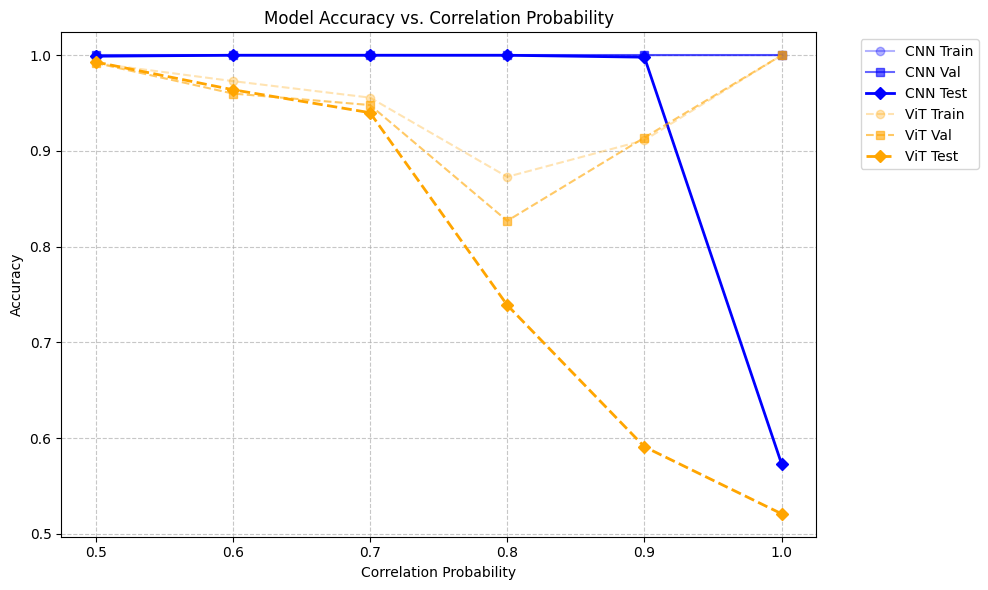

In [ ]:
from lightning.pytorch.callbacks import EarlyStopping
def run_experiment(
      model: nn.Module,
      dm: ShapeDataModule,
      max_epochs:int=20,
      lr:float=1e-3
    ):

    lit_model = ClassifierModule(model, lr=lr)

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='auto',
        enable_model_summary=True,
        callbacks=[
            EarlyStopping(
                monitor='val/loss',
                mode='min',
                patience=5
              )
            ],
        log_every_n_steps=1,
    )

    trainer.fit(lit_model, datamodule=dm)
    metrics = trainer.logged_metrics
    val_acc = metrics['val/acc'].item()
    train_acc = metrics['train/acc'].item()

    test_results = trainer.test(lit_model, datamodule=dm)

    return {
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_results[0]['test/acc']
    }

def main():
    pl.seed_everything(42)
    CORR_PROBS = [0.5, 0.6, 0.7, 0.8, 0.9, 1]

    results = {
        "CNN": {"train": [], "val": [], "test": []},
        "ViT": {"train": [], "val": [], "test": []}
    }

    cfg = DatasetConfig()

    for corr_prob in CORR_PROBS:
        dm = ShapeDataModule(corr_prob=corr_prob, cfg=cfg)
        dm.setup()

        cnn_res = run_experiment(
            SimpleCNN(
              H=cfg.IMG_SIZE,
              W=cfg.IMG_SIZE,
              num_classes=2),
            dm
        )
        results["CNN"]["train"].append(cnn_res['train_acc'])
        results["CNN"]["val"].append(cnn_res['val_acc'])
        results["CNN"]["test"].append(cnn_res['test_acc'])

        vit_res = run_experiment(
            ViT(
              H=cfg.IMG_SIZE,
              W=cfg.IMG_SIZE,
              patch_size=8,
              embed_dim=12,
              depth=2,
              n_heads=2
            ),
            dm
        )
        results["ViT"]["train"].append(vit_res['train_acc'])
        results["ViT"]["val"].append(vit_res['val_acc'])
        results["ViT"]["test"].append(vit_res['test_acc'])


    plt.figure(figsize=(10, 6))

    # Plot CNN (Solid lines)
    plt.plot(CORR_PROBS, results["CNN"]["train"], 'o-', label='CNN Train', color='blue', alpha=0.3)
    plt.plot(CORR_PROBS, results["CNN"]["val"], 's-', label='CNN Val', color='blue', alpha=0.6)
    plt.plot(CORR_PROBS, results["CNN"]["test"], 'D-', label='CNN Test', color='blue', linewidth=2)

    # Plot ViT (Dashed lines)
    plt.plot(CORR_PROBS, results["ViT"]["train"], 'o--', label='ViT Train', color='orange', alpha=0.3)
    plt.plot(CORR_PROBS, results["ViT"]["val"], 's--', label='ViT Val', color='orange', alpha=0.6)
    plt.plot(CORR_PROBS, results["ViT"]["test"], 'D--', label='ViT Test', color='orange', linewidth=2)

    plt.title("Model Accuracy vs. Correlation Probability")
    plt.xlabel("Correlation Probability")
    plt.ylabel("Accuracy")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

main()